# 04 Q4 Cue Portability and Feature Efficacy

Paper-ready single-subfigure exports for Q4.

In [5]:
import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import real_final_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
bar_line_panel = viz.bar_line_panel
load_csv = viz.load_csv
mark_ours_first = viz.mark_ours_first
legend_strip_axes = viz.legend_strip_axes
single_subfigure_axes = viz.single_subfigure_axes
add_legend_strip = viz.add_legend_strip

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp')
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()

In [6]:
portability = load_csv('q4_portability_table.csv').copy()
efficacy = load_csv('q4_feature_efficacy.csv').copy()

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def select_best_hparam_then_average(df, group_cols):
    scored = (
        df.groupby(group_cols + ['base_rank'], as_index=False)[['test_seen_mrr20', 'test_ndcg20', 'test_hit10']]
        .mean()
    )
    best = (
        scored.sort_values(
            group_cols + ['test_seen_mrr20', 'test_ndcg20', 'test_hit10', 'base_rank'],
            ascending=[True] * len(group_cols) + [False, False, False, True],
            kind='stable',
        )
        .drop_duplicates(group_cols, keep='first')
        .sort_values(group_cols, kind='stable')
        .reset_index(drop=True)
    )
    return best

portability['test_seen_mrr20'] = pd.to_numeric(portability['test_seen_mrr20'], errors='coerce')
portability['test_seen_mrr20'] = pd.to_numeric(portability['test_seen_mrr20'], errors='coerce')
portability = portability[portability['status'].astype(str).str.lower() == 'ok'].copy()
portability['test_ndcg20'] = portability['result_path'].apply(lambda p: float((load_json(p).get('test_result') or {}).get('ndcg@20', 0.0)))
portability['test_hit10'] = portability['result_path'].apply(lambda p: float((load_json(p).get('test_result') or {}).get('hit@10', 0.0)))
portability_plot = select_best_hparam_then_average(portability, ['dataset', 'setting_key', 'setting_label', 'variant_order'])
portability_order = ['Full cues', 'No time cues', 'No group cues', 'Sequence cues only']
portability_key_to_display = {
    'full': 'Full cues',
    'remove_time': 'No time cues',
    'remove_category': 'No group cues',
    'portable_core': 'Sequence cues only',
}
portability_plot['variant_display'] = portability_plot['setting_key'].map(portability_key_to_display)
portability_legend = mark_ours_first(portability_order)
portability_palette = {
    'Full cues': PALETTE['route'],
    'Sequence cues only': PALETTE['rose'],
    'No time cues': PALETTE['blue'],
    'No group cues': PALETTE['orange'],
}
portability_colors = [portability_palette[label] for label in portability_order]

efficacy['test_seen_mrr20'] = pd.to_numeric(efficacy['test_seen_mrr20'], errors='coerce')
efficacy['test_seen_mrr20'] = pd.to_numeric(efficacy['test_seen_mrr20'], errors='coerce')
efficacy = efficacy[efficacy['status'].astype(str).str.lower() == 'ok'].copy()
efficacy['test_ndcg20'] = efficacy['result_file'].apply(lambda p: float((load_json(p).get('test_result') or {}).get('ndcg@20', 0.0)))
efficacy['test_hit10'] = efficacy['result_file'].apply(lambda p: float((load_json(p).get('test_result') or {}).get('hit@10', 0.0)))
efficacy_order = ['Intact', 'Cross-sample permute', 'Zero all', 'Intra-seq permute']
efficacy_label_map = {
    'intact': 'Intact',
    'cross_sample_permute': 'Cross-sample permute',
    'zero_all': 'Zero all',
    'position_permute': 'Intra-seq permute',
}
efficacy['variant_display'] = efficacy['intervention'].map(efficacy_label_map).fillna(efficacy['intervention_label'])
efficacy_legend = mark_ours_first(efficacy_order)
efficacy_palette = {
    'Intact': PALETTE['route'],
    'Cross-sample permute': PALETTE['blue'],
    'Zero all': PALETTE['rose'],
    'Intra-seq permute': PALETTE['orange'],
}
efficacy_colors = [efficacy_palette[label] for label in efficacy_order]
print('prepared Q4 rows', len(portability_plot), len(efficacy))

prepared Q4 rows 8 8


[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_portability_a.pdf


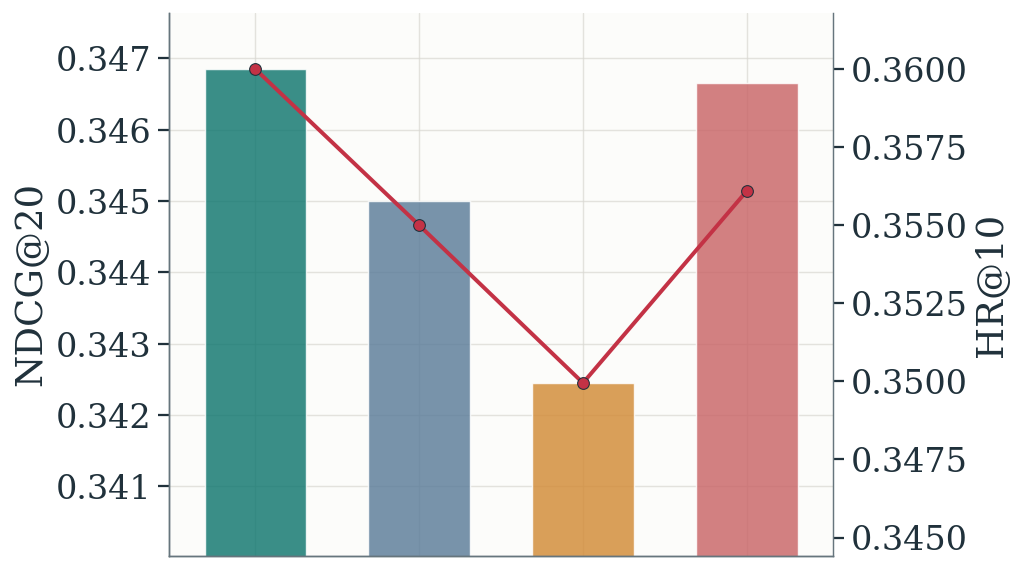

In [7]:
sub = portability_plot[portability_plot['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
fig, ax = single_subfigure_axes()
bar_line_panel(
    sub,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=portability_order,
    xrotation=0,
    palette_override=portability_palette,
    show_xticklabels=False,
    add_metric_legend_box=False,
)
fig.savefig(FIG_DIR / 'fig_q4_portability_a.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_portability_a.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_portability_b.pdf


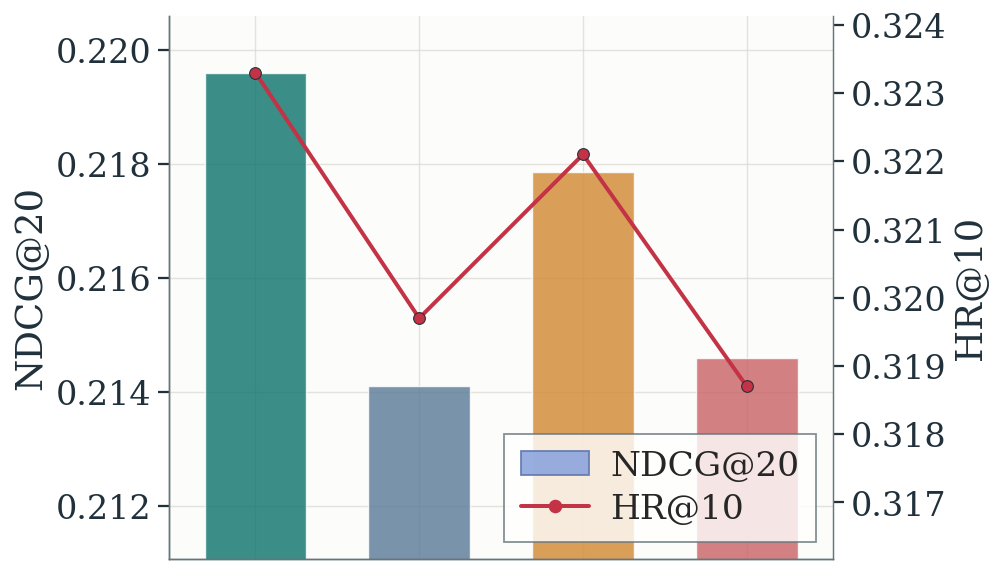

In [8]:
sub = portability_plot[portability_plot['dataset'] == 'foursquare'].copy()
fig, ax = single_subfigure_axes()
bar_line_panel(
    sub,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=portability_order,
    xrotation=0,
    palette_override=portability_palette,
    show_xticklabels=False,
    add_metric_legend_box=True,
)
fig.savefig(FIG_DIR / 'fig_q4_portability_b.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_portability_b.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_portability_legend.pdf


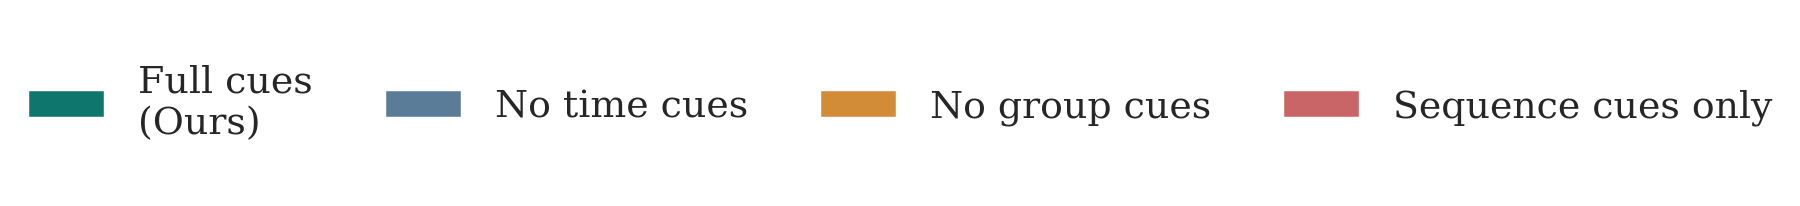

In [9]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, portability_legend, portability_colors)
fig.savefig(FIG_DIR / 'fig_q4_portability_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_portability_legend.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_portability_c.pdf


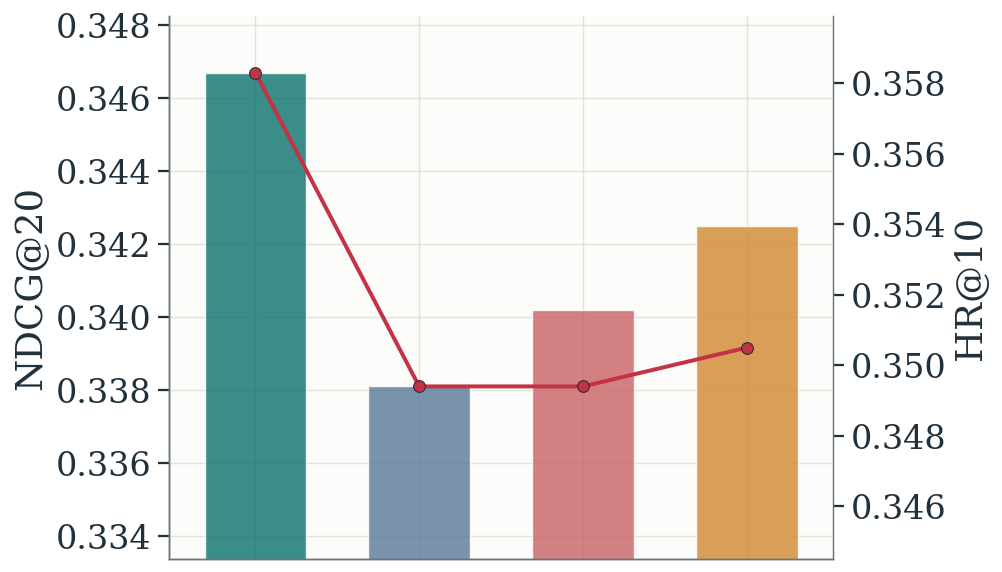

In [10]:
sub = efficacy[efficacy['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
fig, ax = single_subfigure_axes()
bar_line_panel(
    sub,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=efficacy_order,
    xrotation=0,
    palette_override=efficacy_palette,
    show_xticklabels=False,
    add_metric_legend_box=False,
)
fig.savefig(FIG_DIR / 'fig_q4_portability_c.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_portability_c.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_portability_d.pdf


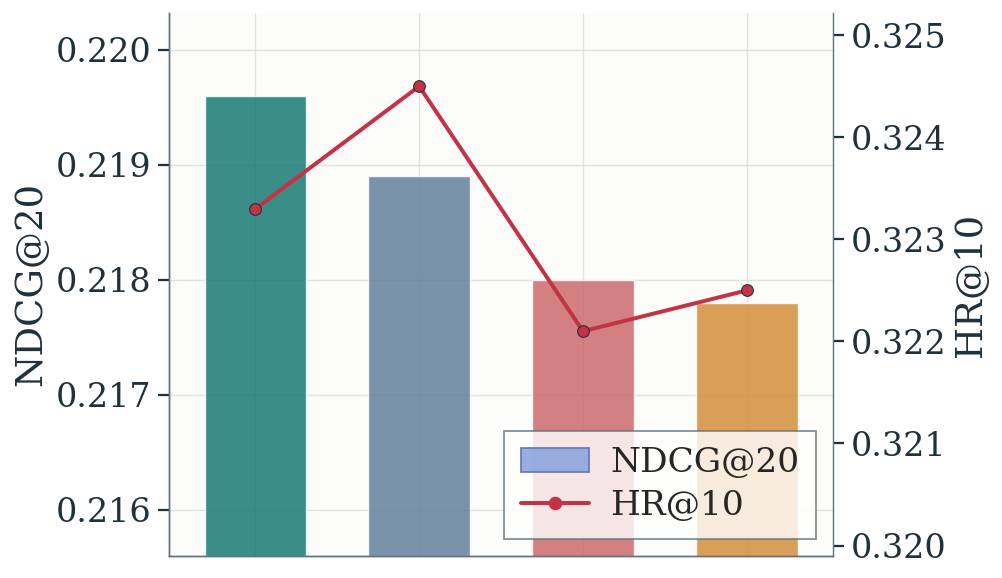

In [11]:
sub = efficacy[efficacy['dataset'] == 'foursquare'].copy()
fig, ax = single_subfigure_axes()
bar_line_panel(
    sub,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=efficacy_order,
    xrotation=0,
    palette_override=efficacy_palette,
    show_xticklabels=False,
    add_metric_legend_box=True,
)
fig.savefig(FIG_DIR / 'fig_q4_portability_d.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_portability_d.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q4_efficacy_legend.pdf


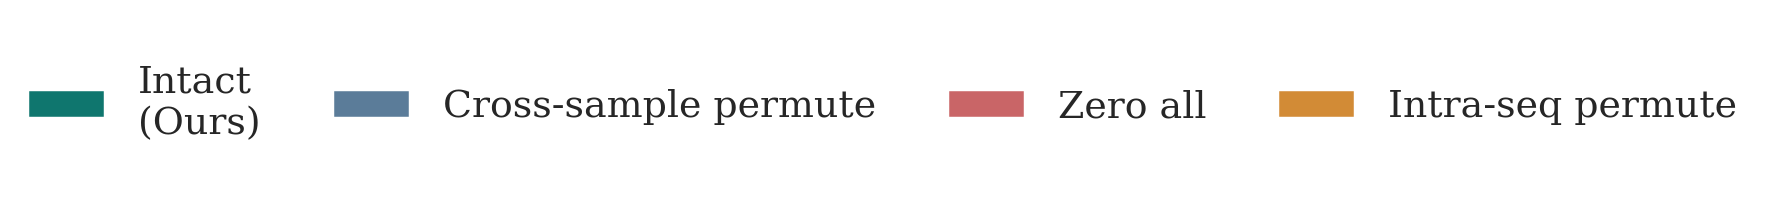

In [12]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, efficacy_legend, efficacy_colors)
fig.savefig(FIG_DIR / 'fig_q4_efficacy_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q4_efficacy_legend.pdf')
plt.show()